## Example the correction result

In [73]:
import numpy as np
import matplotlib.pyplot as plt


def show_distribution_log_scale(array, title):
	fig, ax = plt.subplots(figsize=(8, 4))
	ax.hist(array.ravel(), bins=1000, color='gray')
	ax.set_title(title)
	ax.set_xlabel('Pixel Intensity')
	ax.set_ylabel('Frequency')
	ax.set_yscale('log')
	ax.grid(False)
	plt.show()

def img_show(array, title):
	# Calculate mean along each axis
	mean_x_axis = np.mean(array, axis=0) # Mean along columns
	mean_y_axis = np.mean(array, axis=1) # Mean along rows

	# Create subplots
	fig, ax = plt.subplots(1, 3, figsize=(12, 4)) # One row, three columns

	# Plot the image
	im = ax[0].imshow(array, cmap='rainbow') # Display image in 'rainbow' colormap
	ax[0].set_title('Original Image')
	ax[0].set_xlabel('X-axis (Columns)')
	ax[0].set_ylabel('Y-axis (Rows)')
	fig.colorbar(im, ax=ax[0], orientation='vertical', label='Intensity')


	# Plot the mean along the X-axis
	ax[1].plot(mean_x_axis)
	ax[1].set_title('Mean along X-axis')
	ax[1].set_xlabel('X-axis (Columns)')
	ax[1].set_ylabel('Mean Intensity')

	# Plot the mean along the Y-axis
	ax[2].plot(mean_y_axis, range(len(mean_y_axis))) # Plot against y-axis indices
	ax[2].set_title('Mean along Y-axis')
	ax[2].set_xlabel('Mean Intensity')
	ax[2].set_ylabel('Y-axis (Rows)')
	ax[2].invert_yaxis() # Invert y-axis to match image orientation

	plt.suptitle(title, fontsize=16)
	plt.tight_layout()
	plt.show()

import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 – needed to register the projection

def img_show_surface(
        array,
        title: str = "Surface",
        rstride: int = 10,
        cstride: int = 10,
        vmin=None,
        vmax=None,
        downsample: int = 1
    ):
    """
    Plot a 3‑D surface of a 2‑D NumPy array.

    Parameters
    ----------
    array : np.ndarray
        A 2‑D array (shape ``(m, n)``).  The values are plotted as the z‑axis.
    title : str, optional
        Window / plot title. Default: "Surface".
    cmap : str or Colormap, optional
        Matplotlib colormap used for the surface colours.
    rstride : int, optional
        Row stride – how many rows to skip when drawing the mesh.
        Useful for very dense data; default is 1 (draw every row).
    cstride : int, optional
        Column stride – analogous to ``rstride`` but along columns.
    vmin, vmax : float, optional
        Minimum / maximum values used for colour scaling. If omitted,
        the min/max of ``data`` are used automatically.
    downsample : int, optional
        Factor by which to subsample *both* axes before plotting.
        Setting this to 2 will keep every other row and column (effectively a
        4‑fold reduction in point count).  This is handy for huge images
        such as 2560×2048 where drawing the full grid would be slow.

    Returns
    -------
    fig, ax : matplotlib.figure.Figure, mpl_toolkits.mplot3d.Axes3D
        The figure and axes objects – you can further customise them if
        desired (e.g. add text, change limits, etc.).

    Notes
    -----
    * For a 2560×2048 array the full surface has ~5 million points.
      Plotting that many triangles is expensive; try ``downsample=2`` or
      use larger strides to keep the plot snappy.
    * If you need an interactive, high‑performance viewer for very large
      data sets consider using **Plotly** or **Mayavi** (see the short example
      below).
    """
    # ---- sanity checks -------------------------------------------------
    if not isinstance(array, np.ndarray):
        raise TypeError("data must be a NumPy array")
    if array.ndim != 2:
        raise ValueError("data must be 2‑D")

    # ---- optional down‑sampling ----------------------------------------
    if downsample > 1:
        array = array[::downsample, ::downsample]
        rstride = max(1, rstride // downsample)
        cstride = max(1, cstride // downsample)

    m, n = array.shape

    # ---- coordinate grid (x → columns, y → rows) -----------------------
    x = np.arange(n)          # horizontal axis
    y = np.arange(m)          # vertical axis
    X, Y = np.meshgrid(x, y)

    # ---- plot ----------------------------------------------------------
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        -X,
        Y,
        array,
        rstride=rstride,
        cstride=cstride,
        cmap="rainbow",
        linewidth=0,
        antialiased=False,
        vmin=vmin,
        vmax=vmax
    )

    # ---- aesthetics ----------------------------------------------------
    ax.set_xlabel("X (columns)")
    ax.set_ylabel("Y (rows)")
    ax.set_zlabel("Z value")
    ax.set_title(title)
    ax.view_init(elev=30, azim=150, roll=0)


    fig.colorbar(surf, shrink=0.5, aspect=10, label='Z')
    plt.tight_layout()
    plt.show()

    return fig, ax



## correction algorithm

In [74]:
# replaced by a package

import dexa_correction

## Show the correction array

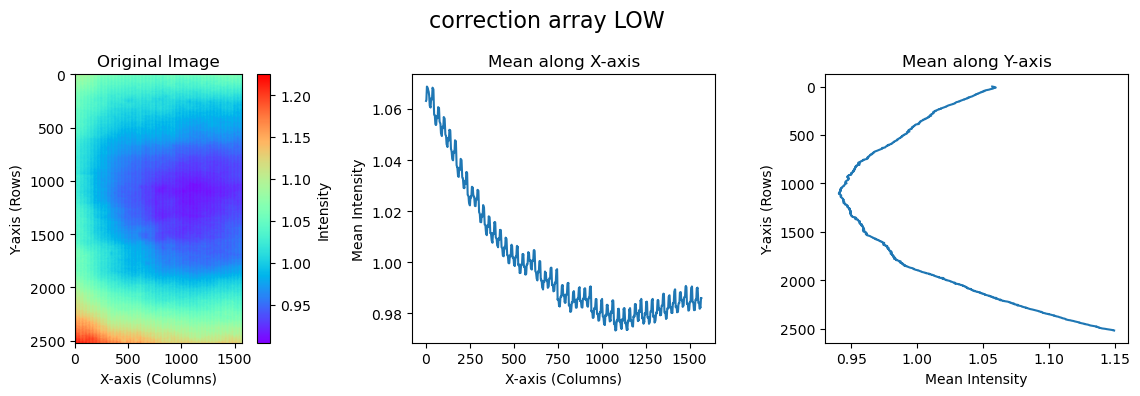

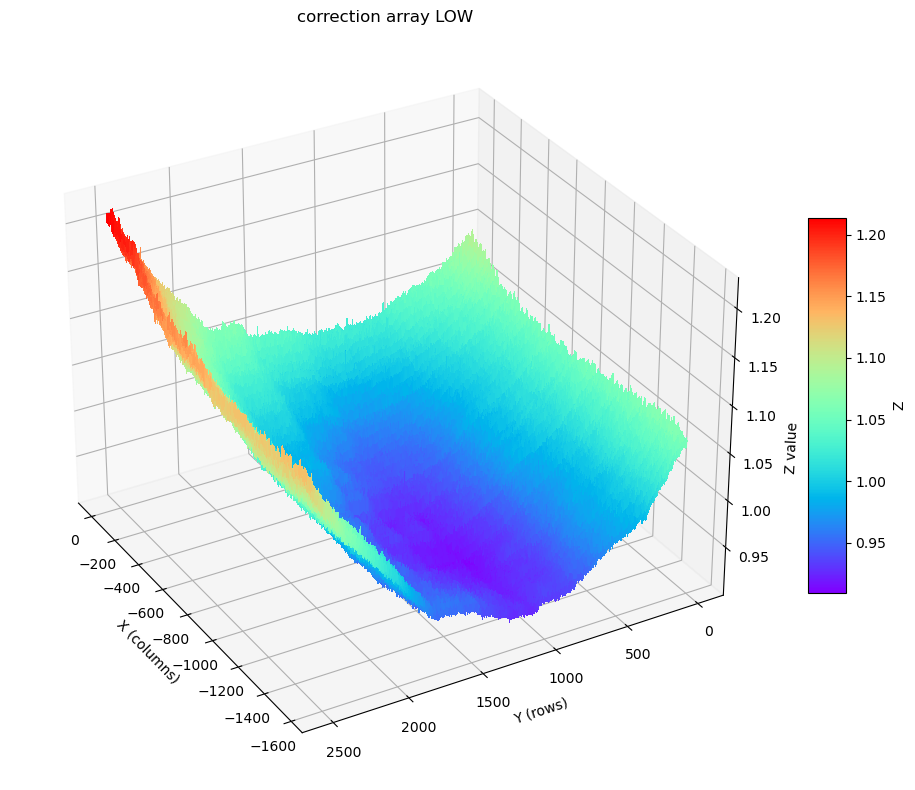

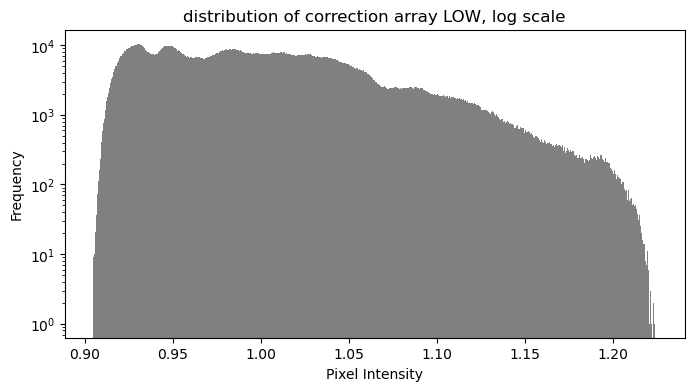

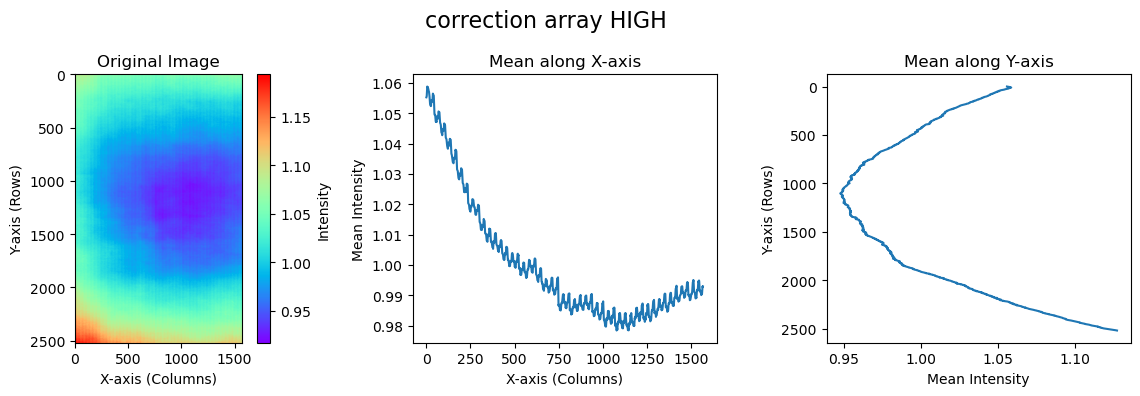

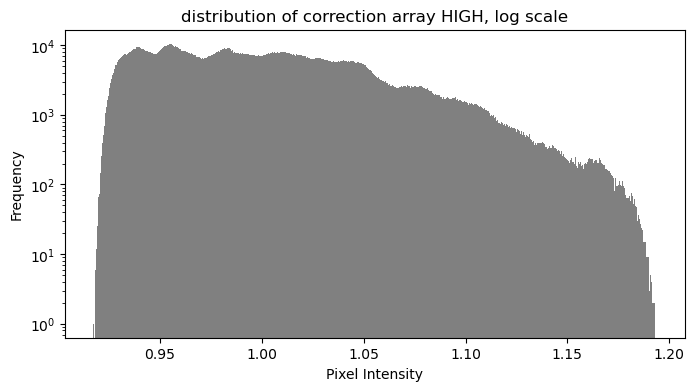

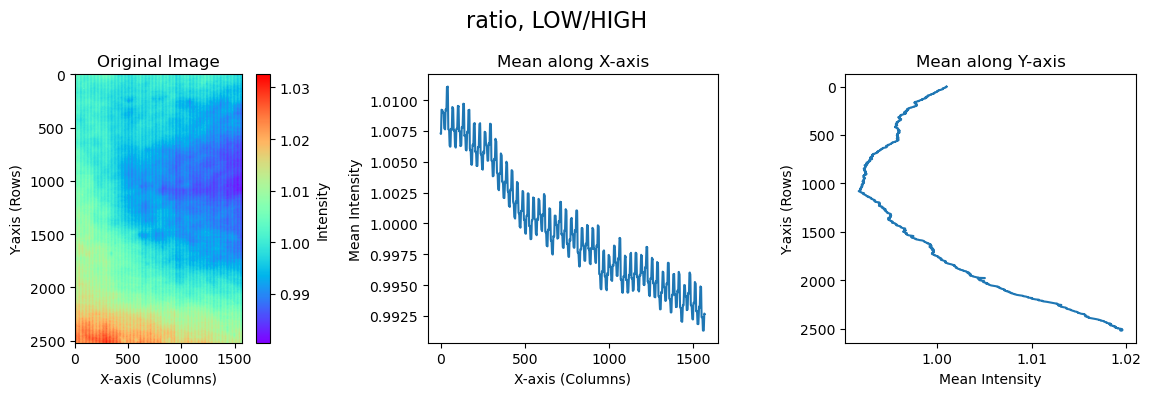

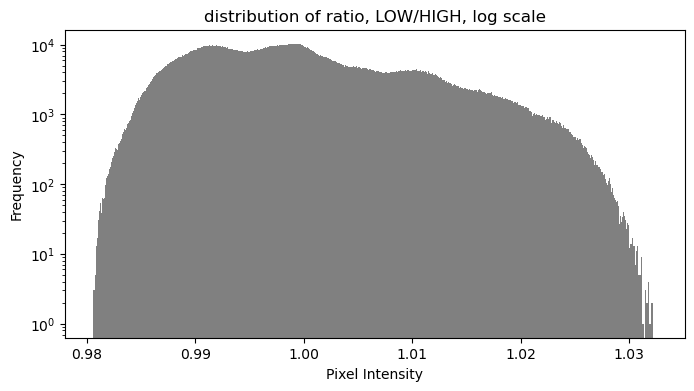

In [75]:
IMAGE_HEIGHT = 2560 - 20 - 20
IMAGE_WIDTH = 2048 - 20 - 460

array_correction_low = np.loadtxt("output/correction_low.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)
array_correction_high = np.loadtxt("output/correction_high.csv").reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_correction_low, "correction array LOW")
img_show_surface(array_correction_low, "correction array LOW")
show_distribution_log_scale(array_correction_low, "distribution of correction array LOW, log scale")
img_show(array_correction_high, "correction array HIGH")
show_distribution_log_scale(array_correction_high, "distribution of correction array HIGH, log scale")

array_ratio = array_correction_low / array_correction_high
img_show(array_ratio, "ratio, LOW/HIGH")
show_distribution_log_scale(array_ratio, "distribution of ratio, LOW/HIGH, log scale")


## Show example corrected image

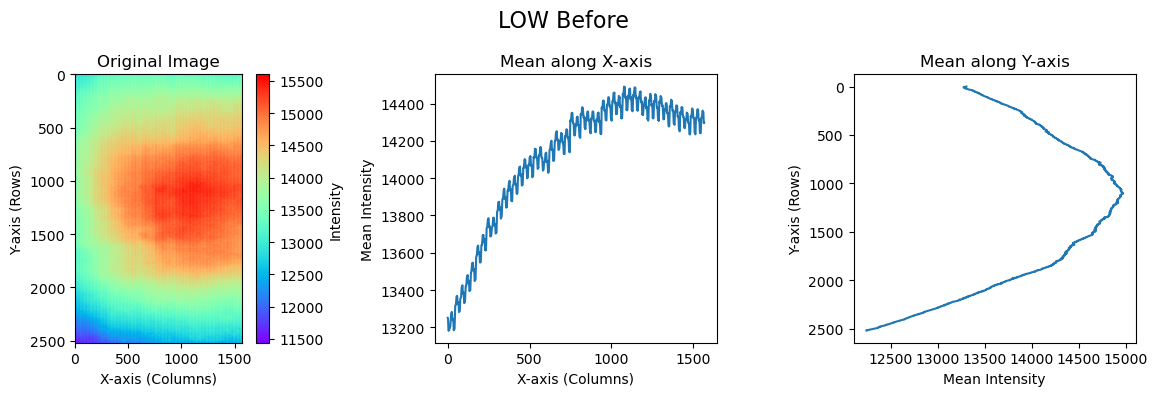

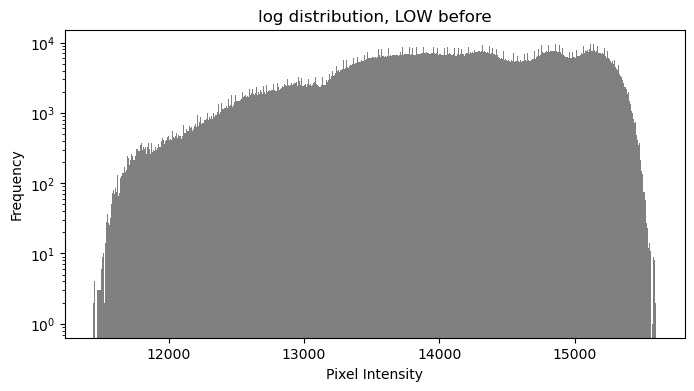

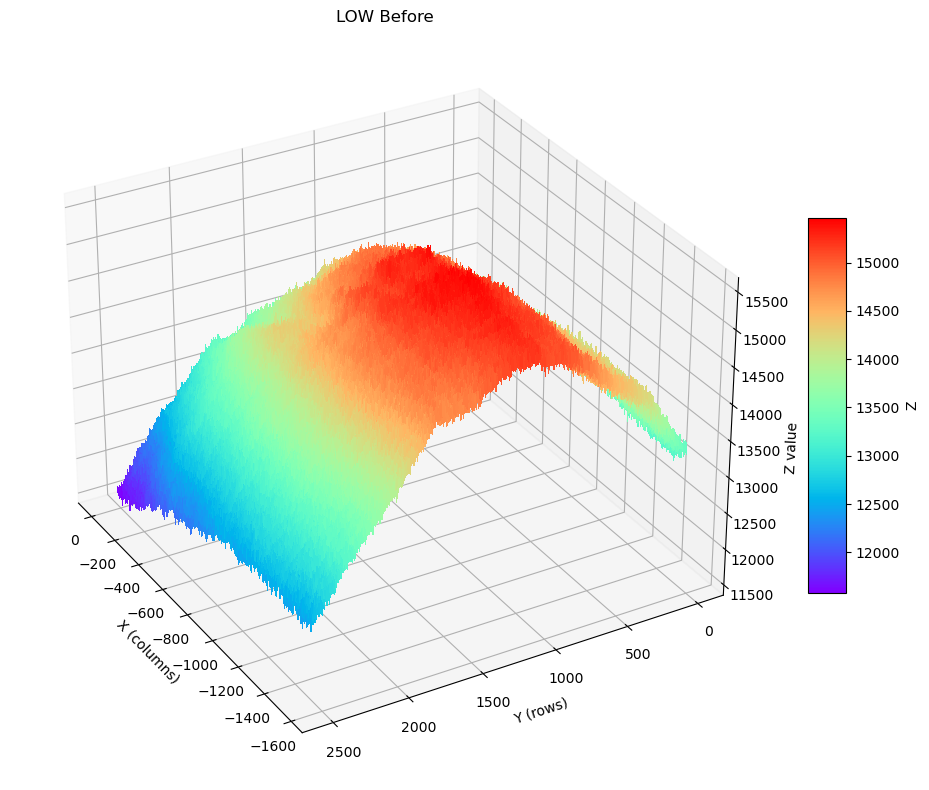

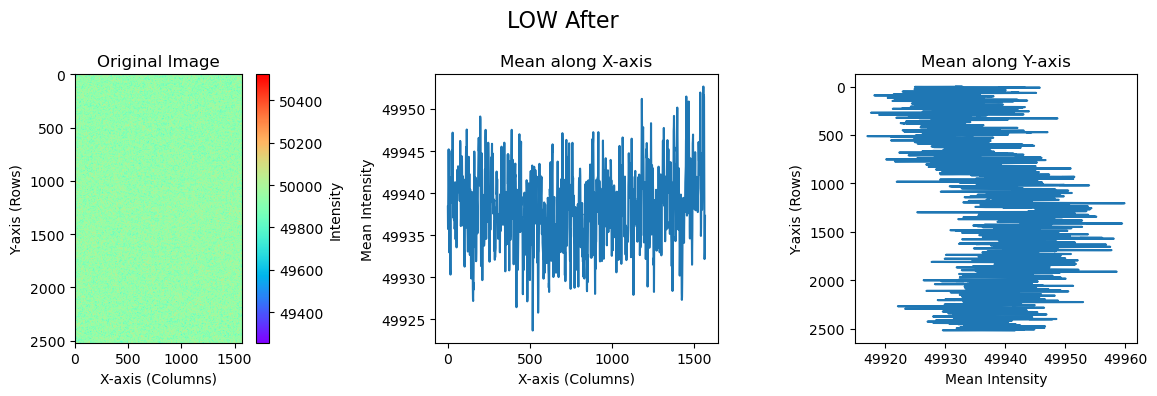

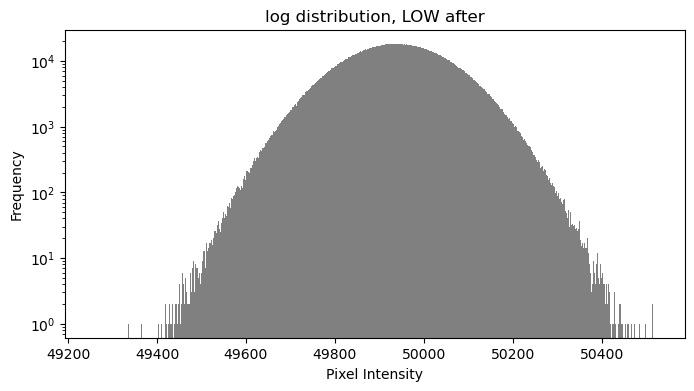

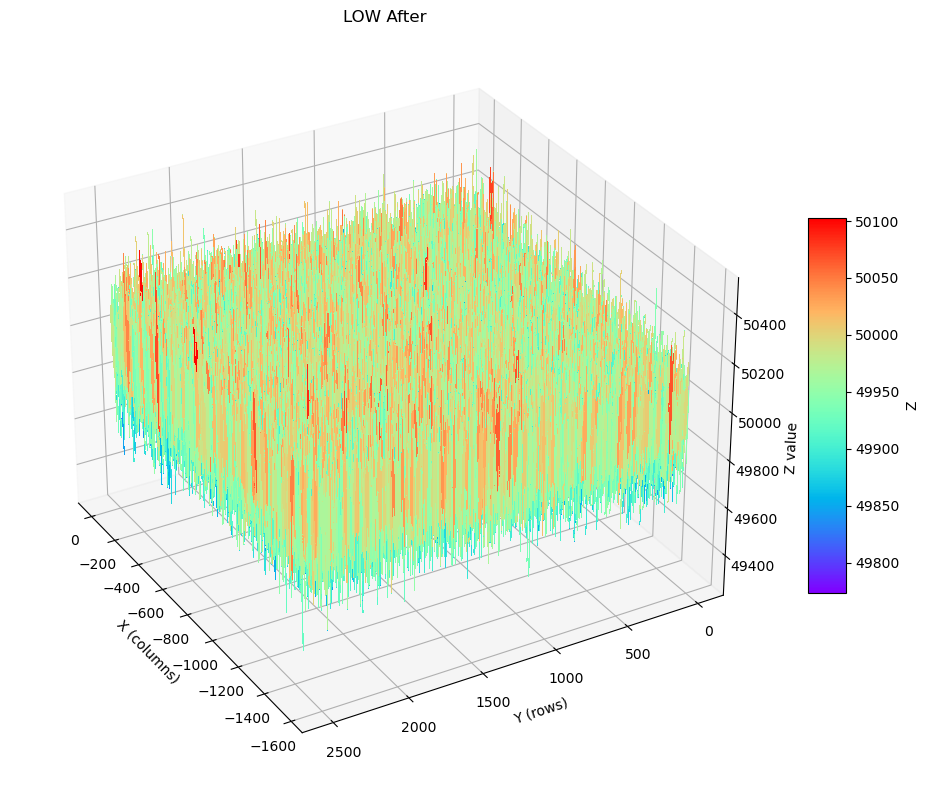

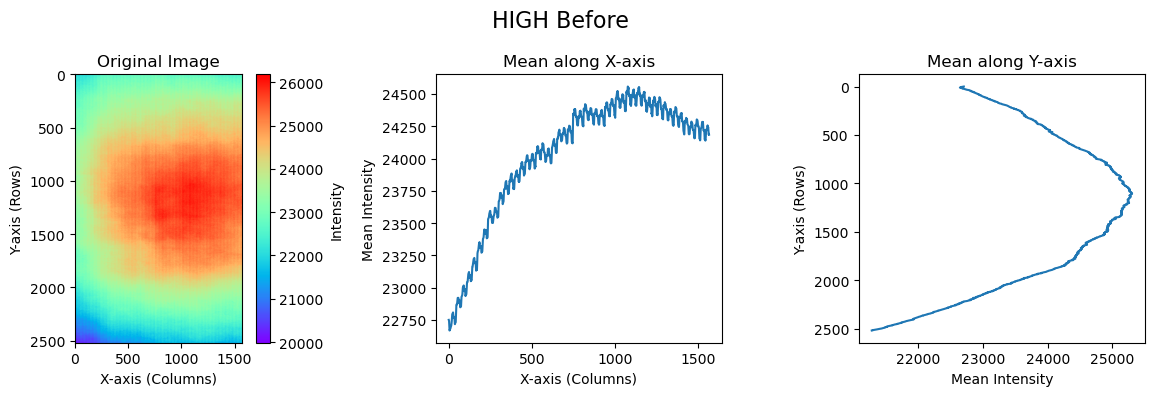

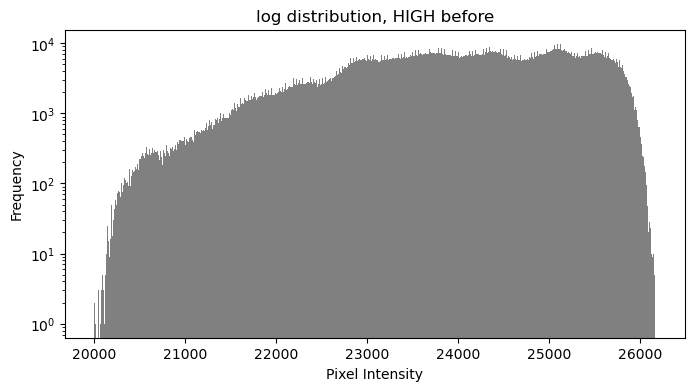

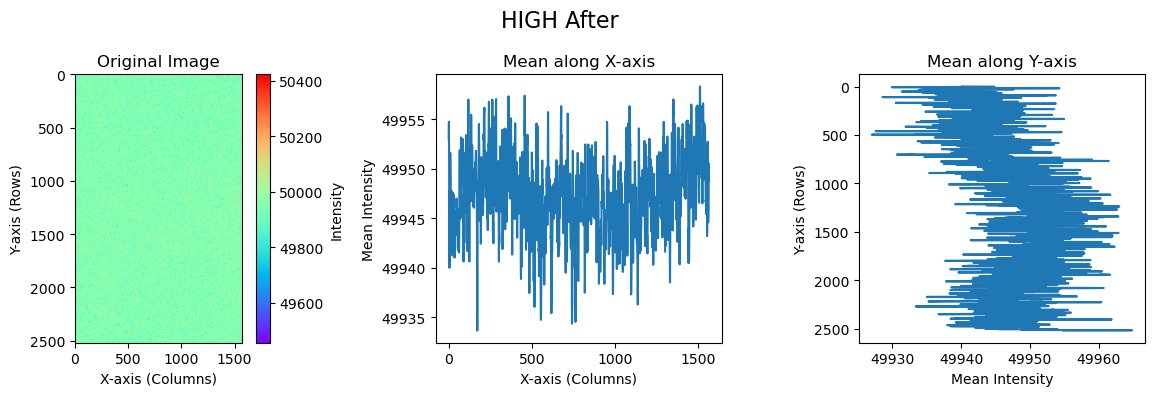

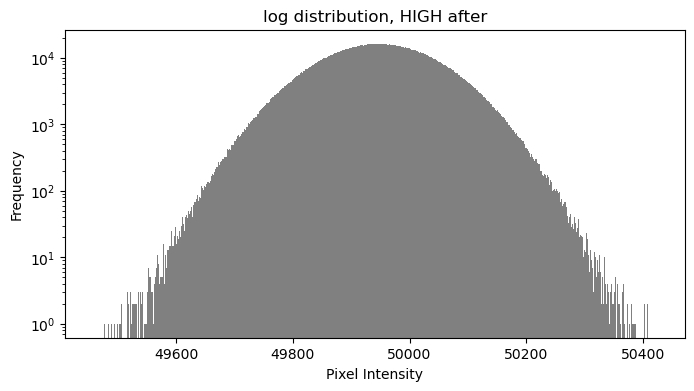

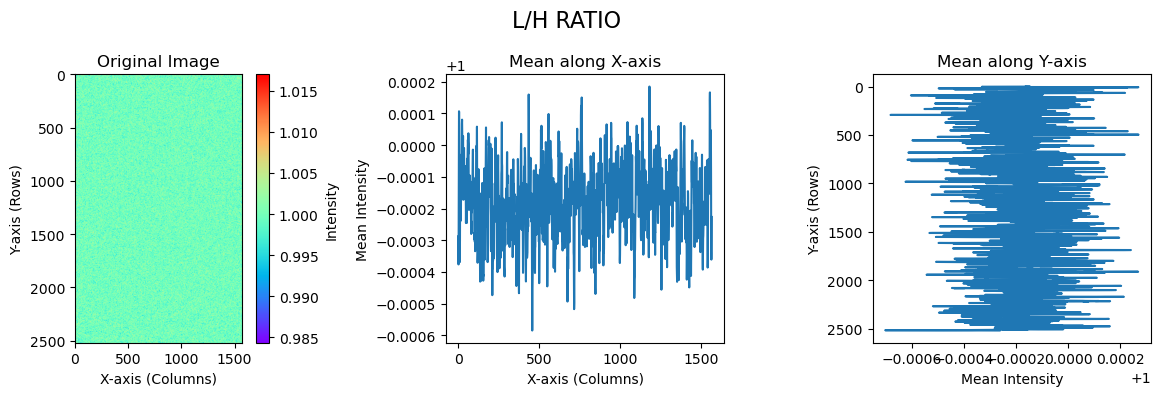

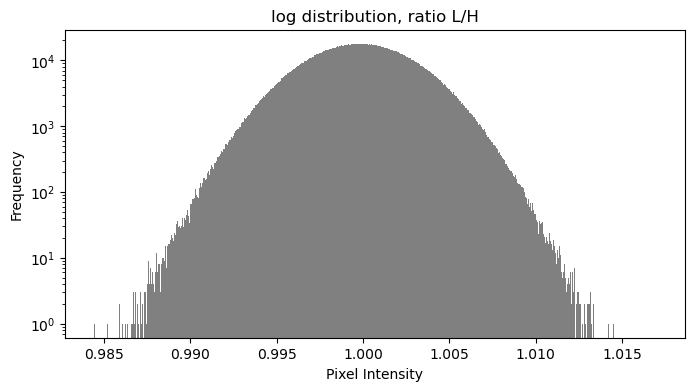

In [76]:

sample = "39"

raw_file_low = f"output/empty/{sample}.raw.low"
raw_file_high = f"output/empty/{sample}.raw.high"

array_low_before = np.fromfile(raw_file_low, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_low_before, "LOW Before")
show_distribution_log_scale(array_low_before, "log distribution, LOW before")
img_show_surface(array_low_before, "LOW Before")

array_low_after = dexa_correction.correct_image(array_low_before, array_correction_low)

img_show(array_low_after, "LOW After")
show_distribution_log_scale(array_low_after, "log distribution, LOW after")
img_show_surface(array_low_after, "LOW After")

array_high_before = np.fromfile(raw_file_high, dtype=np.dtype("<u2")).reshape(IMAGE_HEIGHT, IMAGE_WIDTH)

img_show(array_high_before, "HIGH Before")
show_distribution_log_scale(array_high_before, "log distribution, HIGH before")

array_high_after = dexa_correction.correct_image(array_high_before, array_correction_high)

img_show(array_high_after, "HIGH After")
show_distribution_log_scale(array_high_after, "log distribution, HIGH after")

array_ratio_low_over_high = array_low_after / array_high_after

img_show(array_ratio_low_over_high, "L/H RATIO")
show_distribution_log_scale(array_ratio_low_over_high, "log distribution, ratio L/H")
